QUESTION 1
Customer Shape: (100, 3)
Product Shape: (20, 4)
Order Shape: (300, 5)
Customer data
    Customer_ID        Name       City
0            1  Customer_1  Bangalore
1            2  Customer_2  Hyderabad
2            3  Customer_3      Kochi
3            4  Customer_4  Bangalore
4            5  Customer_5  Bangalore
Product Data
    Product_ID Product_Name  Category  Price
0           1    Product_1      Home   4959
1           2    Product_2  Clothing    479
2           3    Product_3  Clothing    592
3           4    Product_4  Clothing   2162
4           5    Product_5  Clothing   3984
Order data
    Order_ID  Customer_ID  Product_ID  Quantity Order_Date
0         1           23           2         2 2023-11-22
1         2           62           2         1 2023-04-28
2         3           88          19         3 2023-11-20
3         4           37          17         1 2023-10-02
4         5           99          20         1 2023-07-31
Question 2
Customer Columns: Index(['C

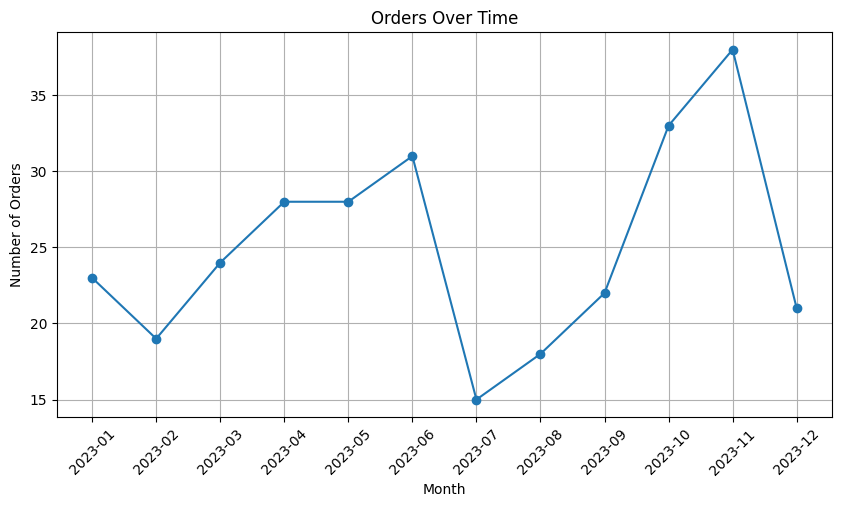

Question 4:


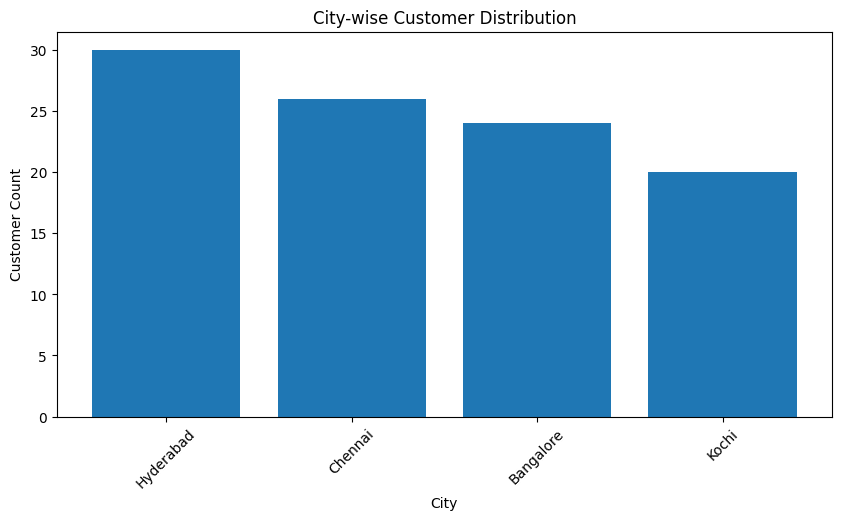

Question 5


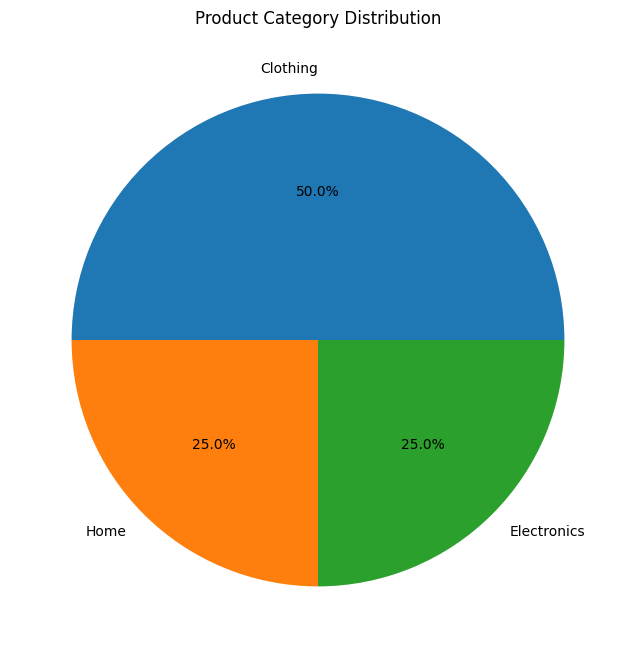

Question 6


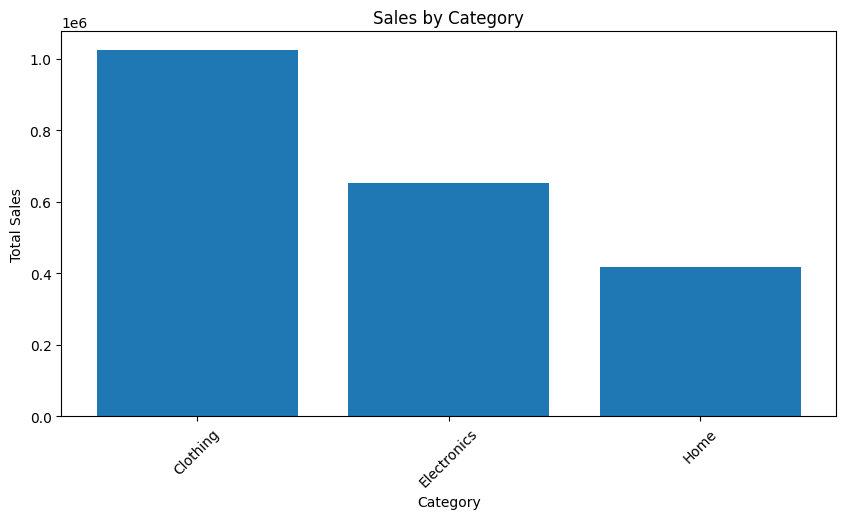

Question 7


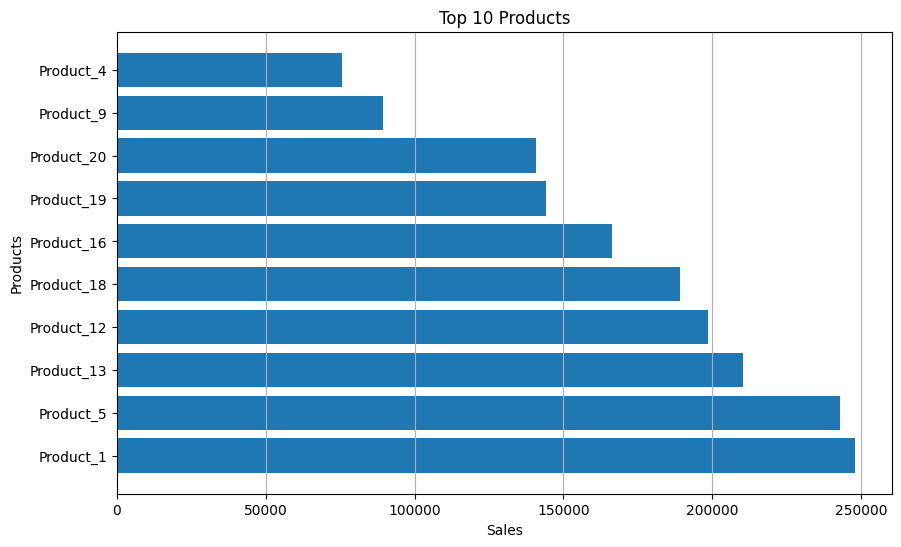

 QUESTION 8


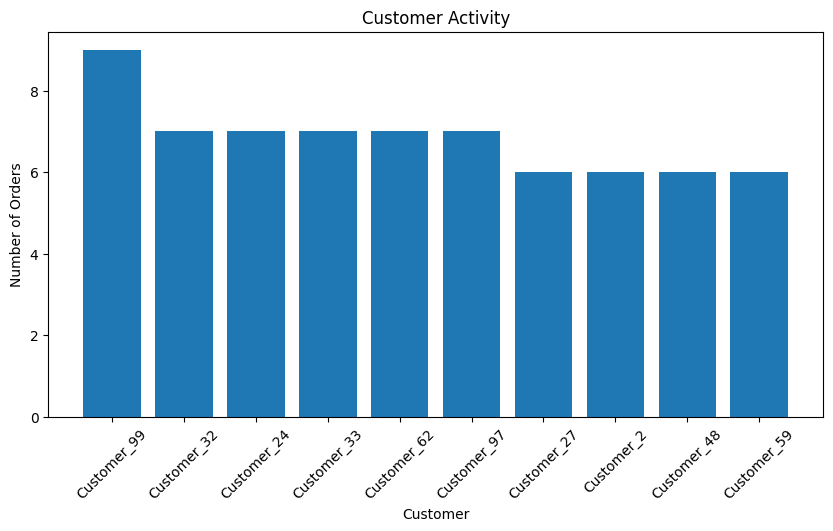

QUESTION 9


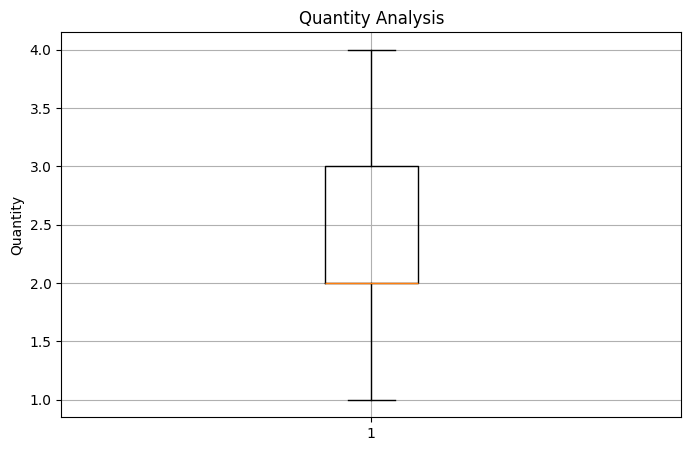

Question 10


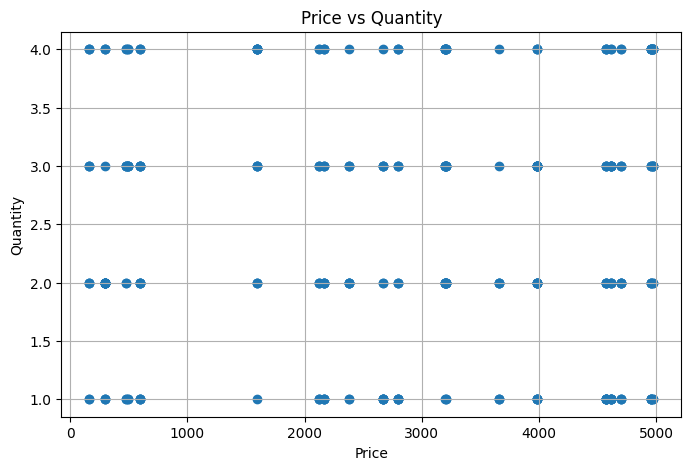

Question 11


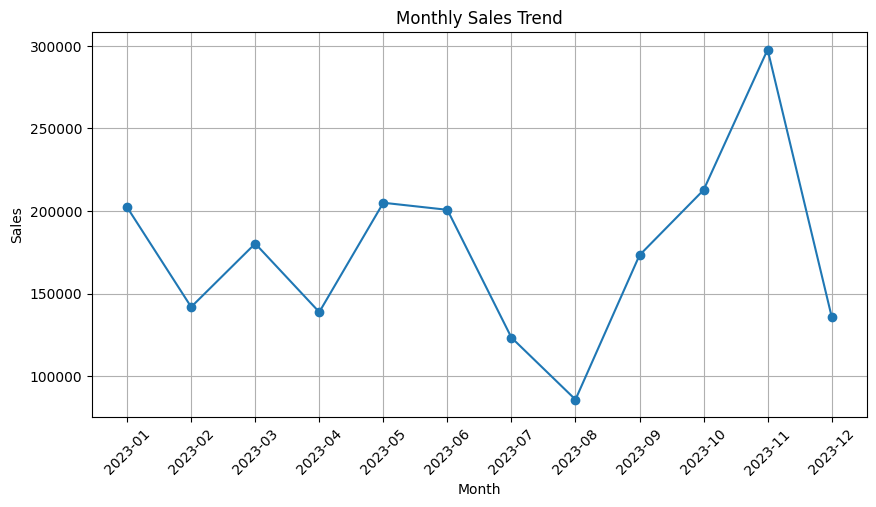

Question 12


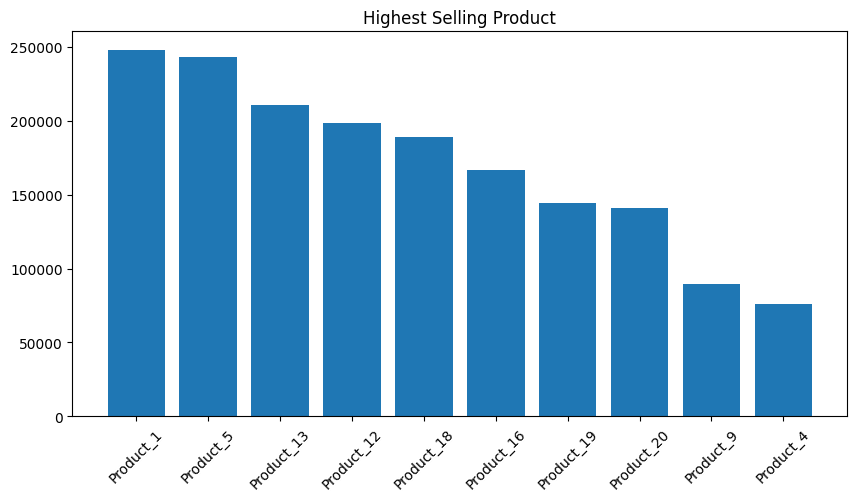

QUESTION 13


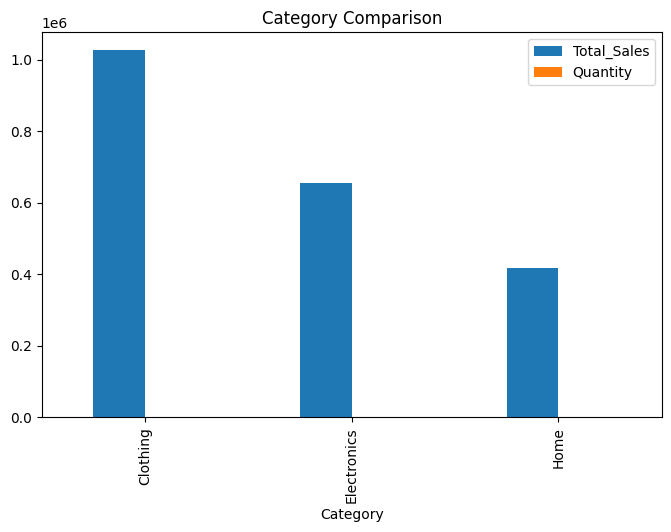

QUESTION 14


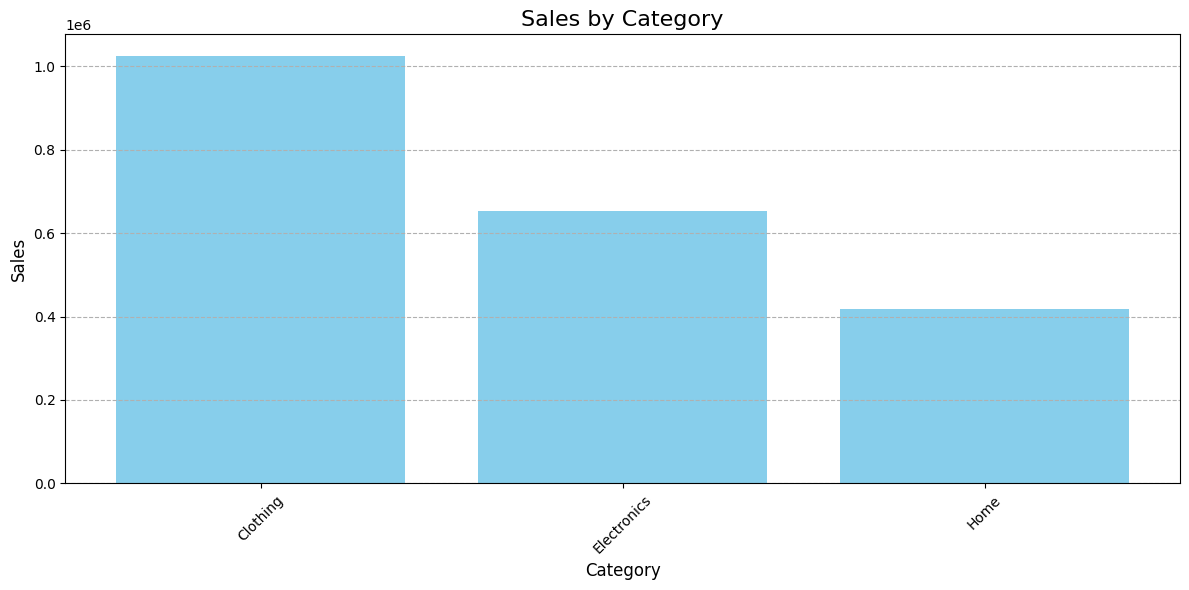

QUESTION 15


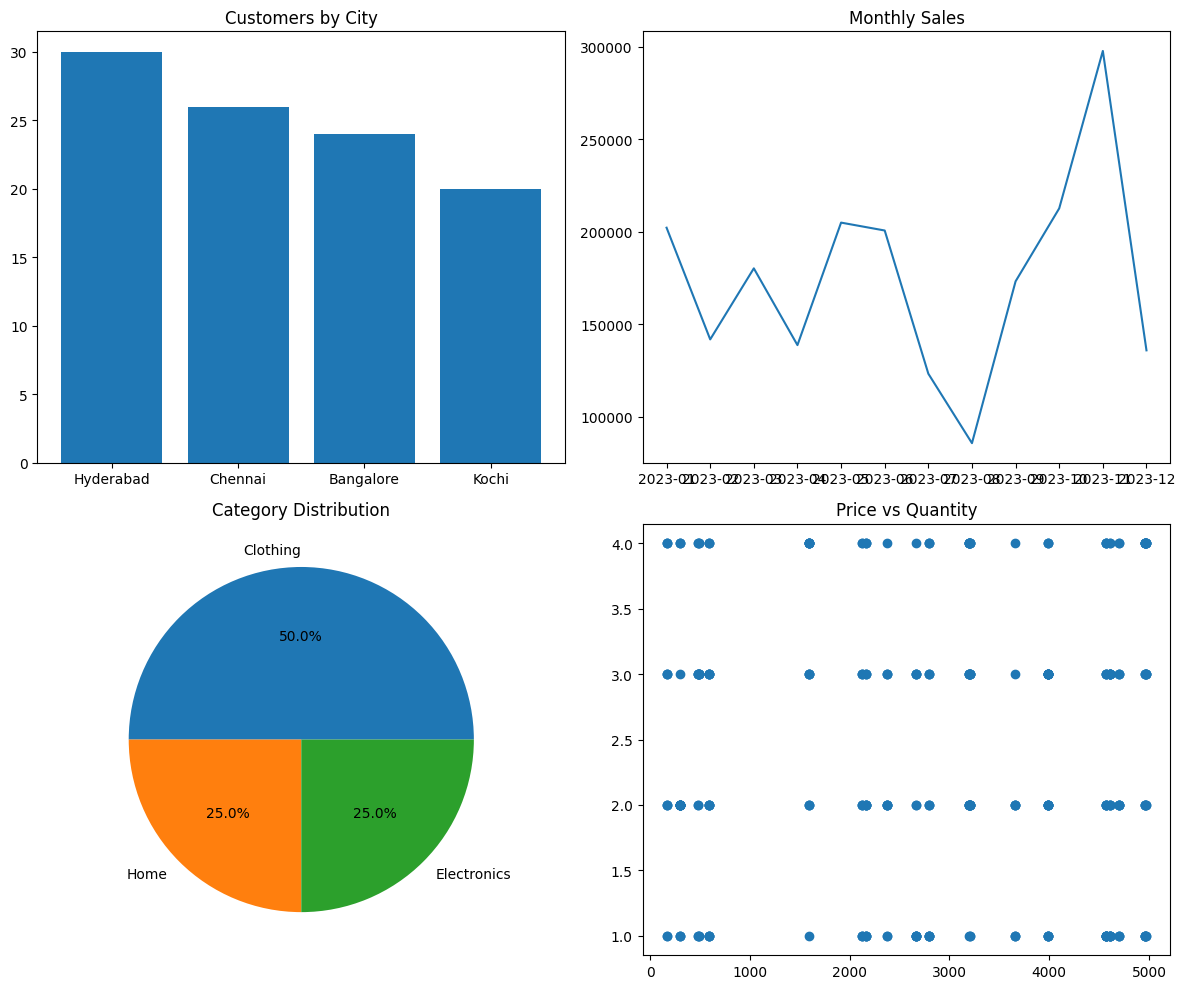

QUESTION 18


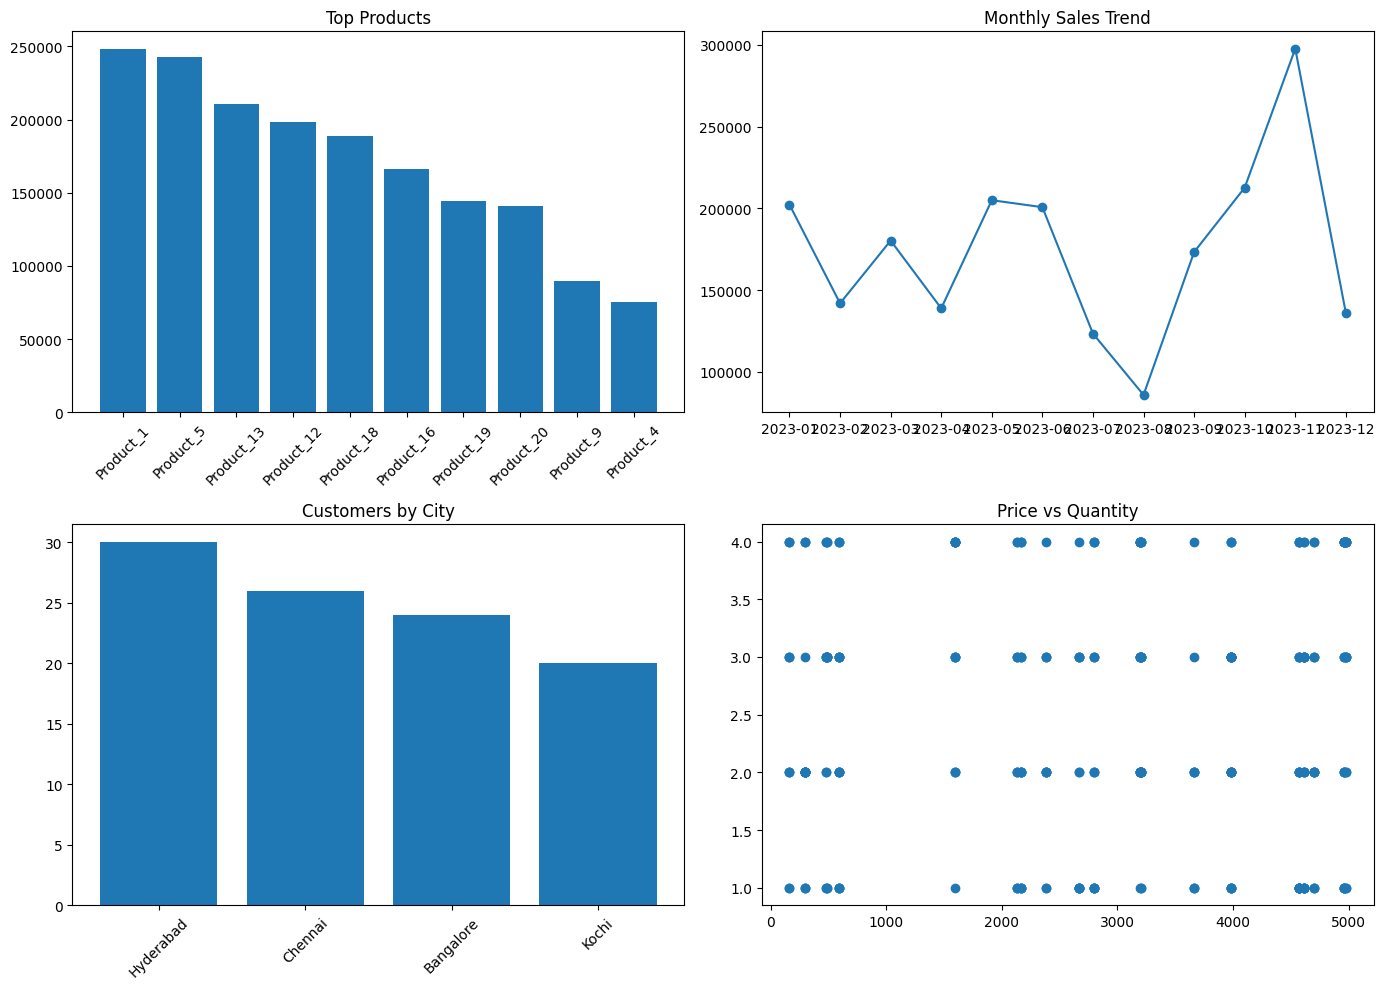

 QUESTION 19


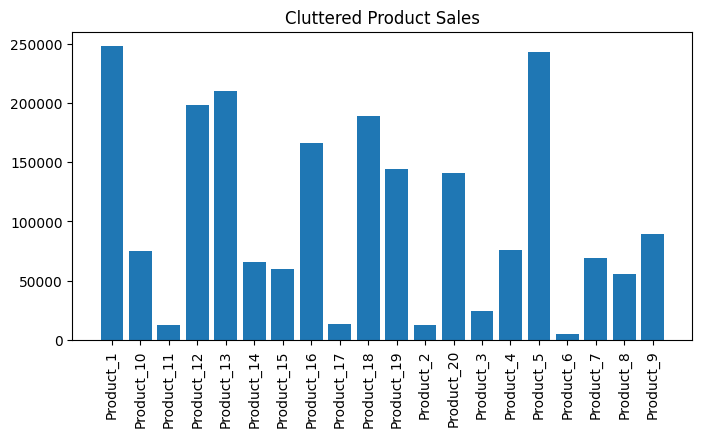

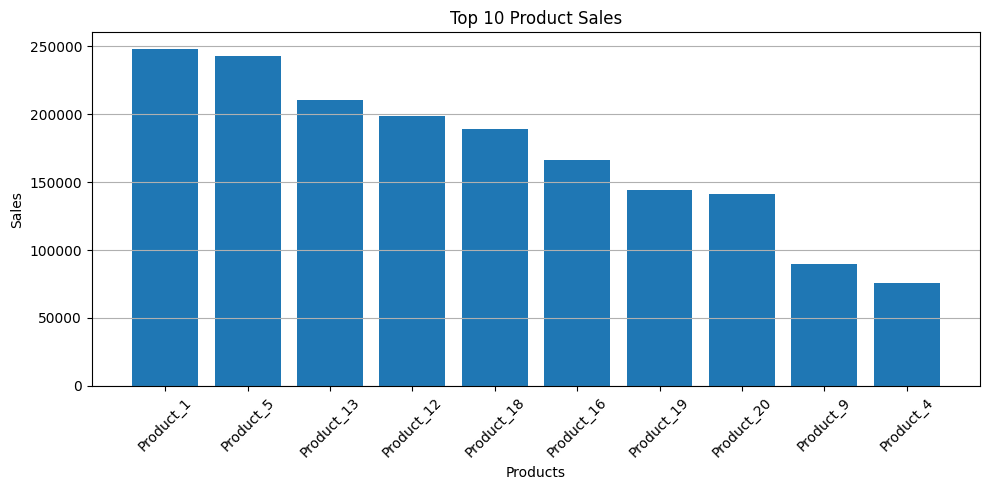

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
#user pandas to read files 
customer = pd.read_excel( "D:\\Srija\\Srija_Data\\matplotlib\\DATASET - Matplotlib Machine Test .xlsx", sheet_name='Customers.xlsx')
product = pd.read_excel("D:\\Srija\\Srija_Data\\matplotlib\\DATASET - Matplotlib Machine Test .xlsx", sheet_name='Products.xlsx')
order = pd.read_excel("D:\\Srija\\Srija_Data\\matplotlib\\DATASET - Matplotlib Machine Test .xlsx",sheet_name='Orders.xlsx')
#Data Understanding
print("QUESTION 1")
print("Customer Shape:", customer.shape) 
print("Product Shape:", product.shape)
print("Order Shape:", order.shape)
print('Customer data\n',customer.head()) #First few records of each sheet
print('Product Data\n',product.head())
print('Order data\n',order.head())
print('Question 2')
print("Customer Columns:", customer.columns)
print("Product Columns:", product.columns)
print("Order Columns:", order.columns)
#Customers connected with Orders using Customer_ID
#Products connected with Orders using Product_ID
#Orders table acts as a bridge table
#data cleaning
print('Question 16')
# Handle Missing or Irregular Data
customer.fillna("Unknown", inplace=True) #replaced null values 
product.fillna(0, inplace=True)
order.fillna(0, inplace=True)
customer.drop_duplicates(inplace=True) # removed duplicates for each data
product.drop_duplicates(inplace=True)
order.drop_duplicates(inplace=True)
merged = pd.merge(order,customer,on='Customer_ID') #used pandas to merge the data
merged = pd.merge(merged,product,on='Product_ID')
merged['Total_Sales'] = (merged['Quantity'] * merged['Price'])
merged['Order_Date'] = pd.to_datetime( merged['Order_Date'])
print("Question 3")
merged['Month'] = merged['Order_Date'].dt.to_period('M')
orders_time = merged.groupby('Month')['Order_ID'].count()
plt.figure(figsize=(10,5))
plt.plot(orders_time.index.astype(str),orders_time.values,marker='o')
plt.title("Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print('Question 4:')
#City-wise Customer Distribution
city_count = customer['City'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(city_count.index,city_count.values)
plt.title("City-wise Customer Distribution")
plt.xlabel("City")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.show()
print("Question 5") 
#Product Category Distribution
category_count = product['Category'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_count.values,labels=category_count.index,autopct='%1.1f%%')
plt.title("Product Category Distribution")
plt.show()
print("Question 6")
#Sales by Category
sales_category = merged.groupby('Category')['Total_Sales'].sum()
plt.figure(figsize=(10,5))
plt.bar(sales_category.index,sales_category.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()
print("Question 7")
#Top Products
top_products = merged.groupby('Product_Name')['Total_Sales'].sum().sort_values( ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_products.index,top_products.values) #Horizontal Bar chart
plt.title("Top 10 Products")
plt.xlabel("Sales")
plt.ylabel("Products")
plt.grid(axis='x')
plt.show()
print(" QUESTION 8")
# Customer Activity
customer_activity = merged.groupby('Name')['Order_ID'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(customer_activity.index, customer_activity.values)
plt.title("Customer Activity")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()
print("QUESTION 9")
#Quantity Analysis
plt.figure(figsize=(8,5))
plt.boxplot(merged['Quantity']) # box plot shows median, spread, outliers
plt.title("Quantity Analysis")
plt.ylabel("Quantity")
plt.grid(True)
plt.show()
print('Question 10')
#Relationship Between Price and Quantity
plt.figure(figsize=(8,5))
plt.scatter(merged['Price'], merged['Quantity']) #scatter shows relationship betwween two variables
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.grid(True)
plt.show()
print('Question 11')
# Monthly Sales Trend
monthly_sales = merged.groupby('Month')['Total_Sales'].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o') #lines chart shows trend
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print('Question 12')
#Highlight Important Data
top_product = merged.groupby('Product_Name')['Total_Sales'].sum().sort_values( ascending=False).head(10)
plt.figure(figsize=(10,5))
bars = plt.bar(top_product.index,top_product.values)
plt.title("Highest Selling Product")
plt.xticks(rotation=45)
plt.show()
print("QUESTION 13")
#Compare Categories
compare = merged.groupby('Category').agg({'Total_Sales':'sum', 'Quantity':'sum'})
compare.plot(kind='bar', figsize=(8,5))
plt.title("Category Comparison")
plt.show()
print("QUESTION 14")
#Improve Chart Appearance
plt.figure(figsize=(12,6))
plt.bar(sales_category.index,sales_category.values,color='skyblue')
plt.title("Sales by Category",fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Sales", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--')
plt.tight_layout()
plt.show()
print("QUESTION 15")
# Multi-Chart Layout
fig, axes = plt.subplots(2,2,figsize=(12,10))
axes[0,0].bar(city_count.index,city_count.values) # bar chart
axes[0,0].set_title("Customers by City")
axes[0,1].plot(monthly_sales.index.astype(str),monthly_sales.values) #line chart
axes[0,1].set_title("Monthly Sales")
axes[1,0].pie(category_count.values,labels=category_count.index,autopct='%1.1f%%') # pie chart
axes[1,0].set_title("Category Distribution")
axes[1,1].scatter(merged['Price'], merged['Quantity']) #scatter chart
axes[1,1].set_title("Price vs Quantity")
plt.tight_layout()
plt.show()
# Save Charts
plt.figure(figsize=(8,5))
plt.bar(sales_category.index,sales_category.values)
plt.title("Sales by Category")
plt.savefig("sales_chart.png")
plt.savefig("sales_chart.pdf")
plt.close()
print("QUESTION 18")
#Final Dashboard Chart
fig, axes = plt.subplots(2,2,figsize=(14,10))
axes[0,0].bar(top_products.index,top_products.values) #bar chart
axes[0,0].set_title("Top Products")
axes[0,0].tick_params(axis='x',rotation=45)
axes[0,1].plot(monthly_sales.index.astype(str),monthly_sales.values,marker='o')
axes[0,1].set_title("Monthly Sales Trend")
axes[1,0].bar(city_count.index,city_count.values)
axes[1,0].set_title("Customers by City")
axes[1,0].tick_params(axis='x',rotation=45)
axes[1,1].scatter(merged['Price'],merged['Quantity'])
axes[1,1].set_title("Price vs Quantity")
plt.tight_layout()
plt.show()
print(" QUESTION 19")
all_products = merged.groupby('Product_Name')['Total_Sales'].sum() #cluttered data
plt.figure(figsize=(8,4))
plt.bar(all_products.index,all_products.values)
plt.title("Cluttered Product Sales")
plt.xticks(rotation=90)
plt.show()
improved = all_products.sort_values(ascending=False).head(10) # modified data
plt.figure(figsize=(10,5))
plt.bar(improved.index, improved.values)
plt.title("Top 10 Product Sales")
plt.xlabel("Products")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()